**[DEMO]** - protocol is packaged in `lightstim/protocols/gate_teleport.py`; this notebook imports and demonstrates it.

# Logical S-Gate Teleportation

Two-patch S-state teleportation with either a ZZ lattice-surgery measurement or a transversal-CNOT teleportation layer.  The |Y> resource patch can be prepared by non-FT injection or, for the unrotated surface code, by FT logical S on |+>.

In [19]:
from pathlib import Path
import sys
import io, contextlib
import numpy as np

ROOT = Path('../..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lightstim.protocols.gate_teleport import SGateTeleportExperiment

In [20]:
configs = {
    "ZZ + logical_gate": dict(code="unrotated_sc", method="ZZ", state_prep="logical_gate"),
    "ZZ + inject": dict(code="unrotated_sc", method="ZZ", state_prep="inject"),
    "cnot_trans + logical_gate": dict(code="unrotated_sc", method="cnot_trans", state_prep="logical_gate"),
    "cnot_trans + inject": dict(code="unrotated_sc", method="cnot_trans", state_prep="inject"),
}

circuits = {}
for label, kwargs in configs.items():
    exp = SGateTeleportExperiment(distance=3, rounds_prep=2, rounds_gate=2, **kwargs)
    with contextlib.redirect_stdout(io.StringIO()):
        circuit = exp.build()
    circuits[label] = circuit
    print(f"{label:26} qubits={circuit.num_qubits:3d} detectors={circuit.num_detectors:3d} observables={circuit.num_observables}")

ZZ + logical_gate          qubits= 55 detectors=147 observables=1
ZZ + inject                qubits= 55 detectors= 97 observables=1
cnot_trans + logical_gate  qubits= 50 detectors=144 observables=1
cnot_trans + inject        qubits= 50 detectors= 94 observables=1


## DetSlice Diagram

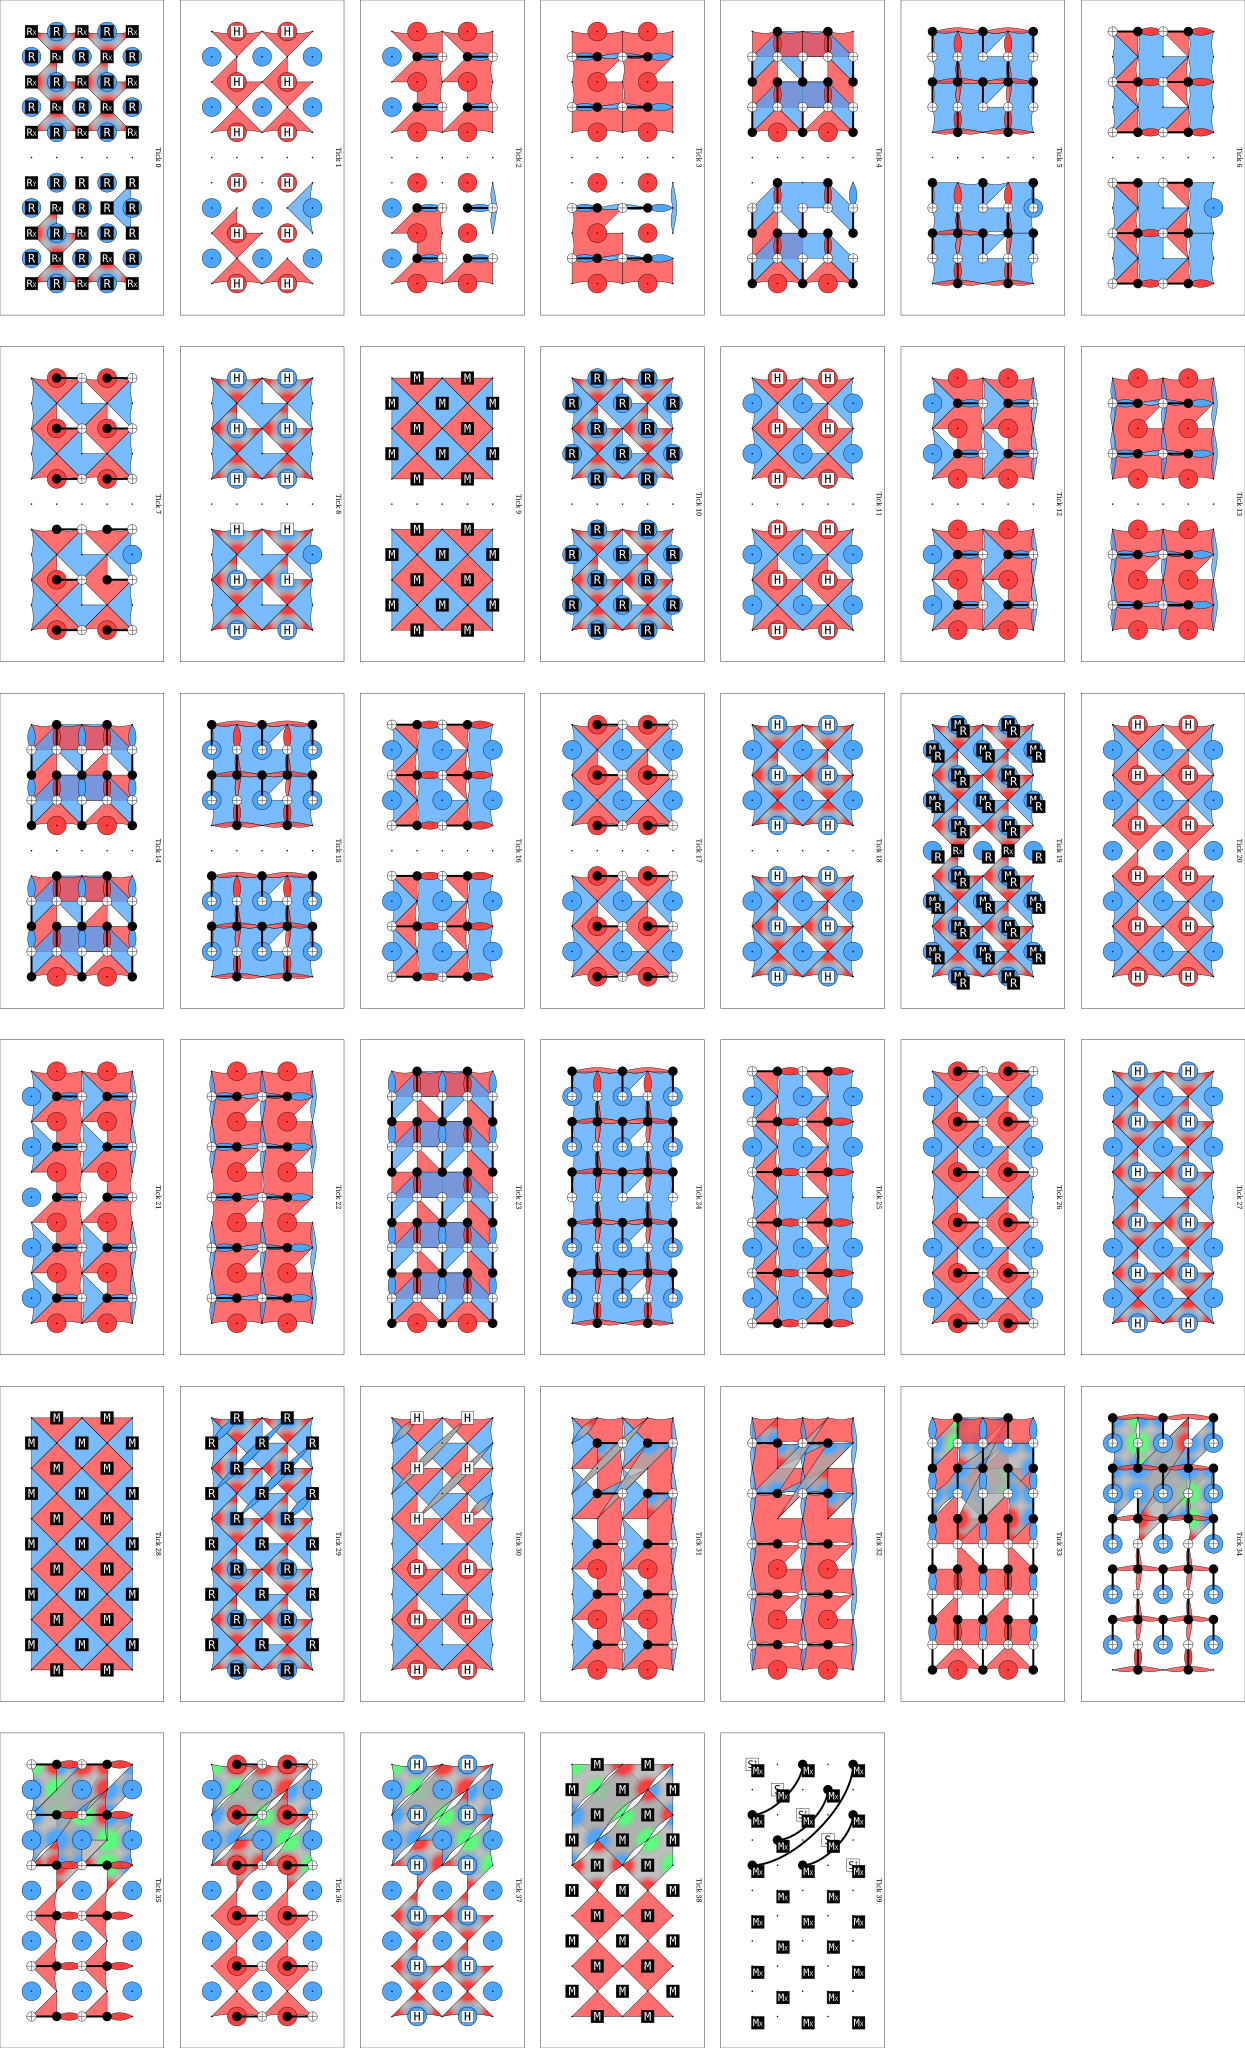

In [21]:
circuits["ZZ + inject"].without_noise().diagram("detslice-with-ops-svg")

## Logical Observable Checks

In [22]:
for label, circuit in circuits.items():
    dem = circuit.flattened().detector_error_model(decompose_errors=True)
    assert circuit.num_observables == 1
    assert dem.num_detectors == circuit.num_detectors
    assert dem.num_observables == circuit.num_observables
    print(f"{label:26} DEM OK: det={dem.num_detectors}, obs={dem.num_observables}")

ZZ + logical_gate          DEM OK: det=147, obs=1
ZZ + inject                DEM OK: det=97, obs=1
cnot_trans + logical_gate  DEM OK: det=144, obs=1
cnot_trans + inject        DEM OK: det=94, obs=1


In [23]:
for label, circuit in circuits.items():
    dets, obs = circuit.compile_detector_sampler(seed=42).sample(
        shots=200,
        separate_observables=True,
    )
    print(f"{label:26} det_errors={np.any(dets)} obs_errors={np.any(obs)}")

ZZ + logical_gate          det_errors=False obs_errors=False
ZZ + inject                det_errors=False obs_errors=False
cnot_trans + logical_gate  det_errors=False obs_errors=False
cnot_trans + inject        det_errors=False obs_errors=False


## Rotated Surface Code Injection Path

In [24]:
for method in ["ZZ", "cnot_trans"]:
    rotated_exp = SGateTeleportExperiment(
        distance=3,
        code="rotated_sc",
        method=method,
        state_prep="inject",
        rounds_prep=2,
        rounds_gate=2,
    )
    with contextlib.redirect_stdout(io.StringIO()):
        rotated_circuit = rotated_exp.build()
    print(f"rotated {method:10} + inject  qubits={rotated_circuit.num_qubits}, detectors={rotated_circuit.num_detectors}, observables={rotated_circuit.num_observables}")
    assert rotated_circuit.num_observables == 1
    rotated_circuit.flattened().detector_error_model(decompose_errors=True)

rotated ZZ         + inject  qubits=41, detectors=63, observables=1
rotated cnot_trans + inject  qubits=34, detectors=59, observables=1


In [25]:
# rotated_circuit.without_noise().diagram("detslice-with-ops-svg")